In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from environment.gridworld import GridWorld
from agent.agent import DQNAgent
from visualize.new_grid_visualize import visualize_gridworld
from environment.grid_map import TileType
from environment.gridworld import Action

# 현재 state를 돌려주는 함수
def get_state_representation(grid_world, agent_pos):
    """
    GridWolrd의 현재 state를 DQN이 이해할 수 있는 형태로 변환
    - 현재 위치 좌표
    - 가장 가까운 목표 지점까지의 상대적 위치
    - 주변 5x5 그리드 정보
    """
    agent_x, agent_y = agent_pos
    grid_size = grid_world.grid_map.padded_size

    # state1: 현재 위치 좌표
    current_pos = np.array([agent_x, agent_y])

    # state2: 가장 가까운 목표 지점까지의 상대적 위치
    min_dist = float('inf')
    nearest_goal = (0, 0)

    # 방문하지 않은 목표 지점이 있는지 확인
    unvisited_goals = [goal for goal in grid_world.goals if goal not in grid_world.visited_goals]
    
    if unvisited_goals:  # 방문하지 않은 목표 지점이 있는 경우
        for goal in unvisited_goals:
            goal_x, goal_y = goal
            dist = abs(goal_x - agent_x) + abs(goal_y - agent_y)
            if dist < min_dist:
                min_dist = dist
                nearest_goal = goal
    
    goal_x, goal_y = nearest_goal
    rel_x = goal_x - agent_x
    rel_y = goal_y - agent_y

    # state3: 주변 5x5 그리드 정보
    local_grid = np.zeros((5, 5))
    for i in range(-2, 3):  # -2, -1, 0, 1, 2
        for j in range(-2, 3):
            nx, ny = agent_x + i, agent_y + j
            if grid_world.grid_map.get_tile_type(nx, ny) == TileType.EMPTY:
                local_grid[i+2, j+2] = 0    # 빈 공간은 0으로 표시
            elif grid_world.grid_map.get_tile_type(nx, ny) == TileType.CONSTRUCTION:
                local_grid[i+2, j+2] = 1    # 건물은 1로 표시
            elif grid_world.grid_map.get_tile_type(nx, ny) == TileType.WALL:
                local_grid[i+2, j+2] = 2  # 벽은 2로 표시
            elif (nx, ny) in grid_world.goals:
                local_grid[i+2, j+2] = 3  # 목표는 3로 표시

    # 모든 정보를 하나의 벡터로 결합
    state = np.concatenate([
        current_pos / grid_size,  # 정규화된 현재 위치
        np.array([rel_x, rel_y]) / grid_size,  # 정규화된 상대적 목표 위치
        local_grid.flatten()  # 5x5 그리드 정보를 1차원으로 변환
    ])

    return state

In [2]:
from environment.config import MapConfig

def train_universal_dqn(episodes=1000, sync_interval=20):
    # 각 시나리오별 환경 생성
    grid_worlds = {
        "시나리오1": GridWorld(
                        size=MapConfig.DEFAULT_SIZE, padding=MapConfig.DEFAULT_PADDING,
                        seed=MapConfig.DEFAULT_SEED, num_walls=MapConfig.DEFAULT_NUM_WALLS,
                        num_construction=MapConfig.DEFAULT_NUM_CONSTRUCTION, scenario_type="시나리오1"
                    ),
        "시나리오2": GridWorld(
                        size=MapConfig.DEFAULT_SIZE, padding=MapConfig.DEFAULT_PADDING,
                        seed=MapConfig.DEFAULT_SEED, num_walls=MapConfig.DEFAULT_NUM_WALLS,
                        num_construction=MapConfig.DEFAULT_NUM_CONSTRUCTION, scenario_type="시나리오2"
                    ),
        "시나리오3": GridWorld(
                        size=MapConfig.DEFAULT_SIZE, padding=MapConfig.DEFAULT_PADDING,
                        seed=MapConfig.DEFAULT_SEED, num_walls=MapConfig.DEFAULT_NUM_WALLS,
                        num_construction=MapConfig.DEFAULT_NUM_CONSTRUCTION, scenario_type="시나리오3"
                    )
    }
    
    # 상태 크기는 가장 큰 시나리오에 맞춤
    state_size = 29  # 현재 상태 표현의 크기
    action_size = 4  # 행동 공간의 크기
    
    # 하나의 DQN 에이전트 생성
    agent = DQNAgent(state_size, action_size)
    
    # 각 시나리오별 성공 횟수와 보상 기록
    scenario_stats = {
        "시나리오1": {"success": 0, "rewards": [], "episodes": 0},
        "시나리오2": {"success": 0, "rewards": [], "episodes": 0},
        "시나리오3": {"success": 0, "rewards": [], "episodes": 0}
    }
    
    for episode in range(episodes):
        # 각 에피소드마다 랜덤하게 시나리오 선택
        scenario_type = np.random.choice(list(grid_worlds.keys()))
        grid_world = grid_worlds[scenario_type]

        # 선택된 시나리오의 에피소드 수 증가
        scenario_stats[scenario_type]["episodes"] += 1
        
        state = grid_world.reset()
        state_representation = get_state_representation(grid_world, state)
        done = False
        total_reward = 0
        steps = 0
        max_steps = 100  # 최대 스텝 수 제한
        
        while not done and steps < max_steps:
            action = agent.get_action(state_representation)
            next_state, reward, done = grid_world.step(Action(action))
            next_state_representation = get_state_representation(grid_world, next_state)
            
            # 에이전트 업데이트
            agent.update(state_representation, action, reward, next_state_representation, done)
            
            state = next_state
            state_representation = next_state_representation
            total_reward += reward
            steps += 1
            
            if done:
                scenario_stats[scenario_type]["success"] += 1
                break
        
        # 시나리오별 보상 기록
        scenario_stats[scenario_type]["rewards"].append(total_reward)
        
        # 타겟 네트워크 동기화
        if episode % sync_interval == 0:
            agent.sync_qnet()
        
        # 학습 진행 상황 출력
        if (episode + 1) % 50 == 0:
            print(f"\nEpisode {episode + 1}")
            for scenario in scenario_stats:
                # 실제 실행된 에피소드 수로 나누어 성공률 계산
                if scenario_stats[scenario]["episodes"] > 0:
                    success_rate = (scenario_stats[scenario]["success"] / 
                                  scenario_stats[scenario]["episodes"]) * 100
                    avg_reward = np.mean(scenario_stats[scenario]["rewards"][-10:]) if scenario_stats[scenario]["rewards"] else 0
                    print(f"{scenario}: Success Rate = {success_rate:.2f}%, "
                          f"Recent Avg Reward = {avg_reward:.2f}, "
                          f"Episodes = {scenario_stats[scenario]['episodes']}")
                else:
                    print(f"{scenario}: No episodes yet")

    return agent, scenario_stats

In [3]:
# 학습
agent, stats = train_universal_dqn(episodes=5000)


Episode 50
시나리오1: Success Rate = 0.00%, Recent Avg Reward = -18.32, Episodes = 13
시나리오2: Success Rate = 96.15%, Recent Avg Reward = -3.87, Episodes = 26
시나리오3: Success Rate = 0.00%, Recent Avg Reward = -18.02, Episodes = 11

Episode 100
시나리오1: Success Rate = 0.00%, Recent Avg Reward = -17.55, Episodes = 29
시나리오2: Success Rate = 97.78%, Recent Avg Reward = -4.04, Episodes = 45
시나리오3: Success Rate = 34.62%, Recent Avg Reward = -5.72, Episodes = 26

Episode 150
시나리오1: Success Rate = 0.00%, Recent Avg Reward = -12.76, Episodes = 46
시나리오2: Success Rate = 98.28%, Recent Avg Reward = 0.11, Episodes = 58
시나리오3: Success Rate = 52.17%, Recent Avg Reward = -10.11, Episodes = 46

Episode 200
시나리오1: Success Rate = 0.00%, Recent Avg Reward = -12.83, Episodes = 66
시나리오2: Success Rate = 98.65%, Recent Avg Reward = 0.22, Episodes = 74
시나리오3: Success Rate = 63.33%, Recent Avg Reward = 0.83, Episodes = 60

Episode 250
시나리오1: Success Rate = 0.00%, Recent Avg Reward = -13.31, Episodes = 89
시나리오2: Success 

In [4]:
import time

def test_agent(grid_world, agent, max_steps=100):
    """
    학습된 에이전트를 테스트하고 시각화합니다.
    테스트 시에는 epsilon을 0으로 설정하여 탐욕적 정책을 사용합니다.
    """
    # 테스트를 위해 epsilon을 0으로 설정
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    state = grid_world.reset()
    state_representation = get_state_representation(grid_world, state)
    done = False
    step = 0
    total_reward = 0

    print("테스트 시작!")
    print(f"시작 위치: {state}")

    try:
        while not done and step < max_steps:
            # 현재 상태 시각화
            visualize_gridworld(grid_world)

            # 행동 선택 및 실행
            action_idx = agent.get_action(state_representation)
            action = Action(action_idx)
            next_state, reward, done = grid_world.step(action)
            next_state_representation = get_state_representation(grid_world, next_state)

            # 결과 출력
            print(f"\n스텝 {step + 1}:")
            print(f"현재 위치: {state}")
            print(f"선택한 행동: {action}")
            print(f"다음 위치: {next_state}")
            print(f"보상: {reward}")

            state = next_state
            state_representation = next_state_representation
            total_reward += reward
            step += 1
            
            time.sleep(0.2)

            if done:
                print("\n목표 도달!")
                break

    finally:
        # 테스트 종료 후 원래의 epsilon 값으로 복원
        agent.epsilon = original_epsilon

    print(f"\n테스트 종료!")
    print(f"총 스텝 수: {step}")
    print(f"총 보상: {total_reward}")
    print(f"목표 도달 여부: {done}")

In [5]:
# 시나리오1 테스트
grid_world_1 = GridWorld(
    size=7,
    padding=2,
    seed=40,
    num_walls=5,
    num_construction=5,
    scenario_type="시나리오1"
)
grid_world_2 = GridWorld(
    size=7,
    padding=2,
    seed=40,
    num_walls=5,
    num_construction=5,
    scenario_type="시나리오2"
)
grid_world_3 = GridWorld(
    size=7,
    padding=2,
    seed=40,
    num_walls=5,
    num_construction=5,
    scenario_type="시나리오3"
)

테스트 시작!
시작 위치: (5, 5)


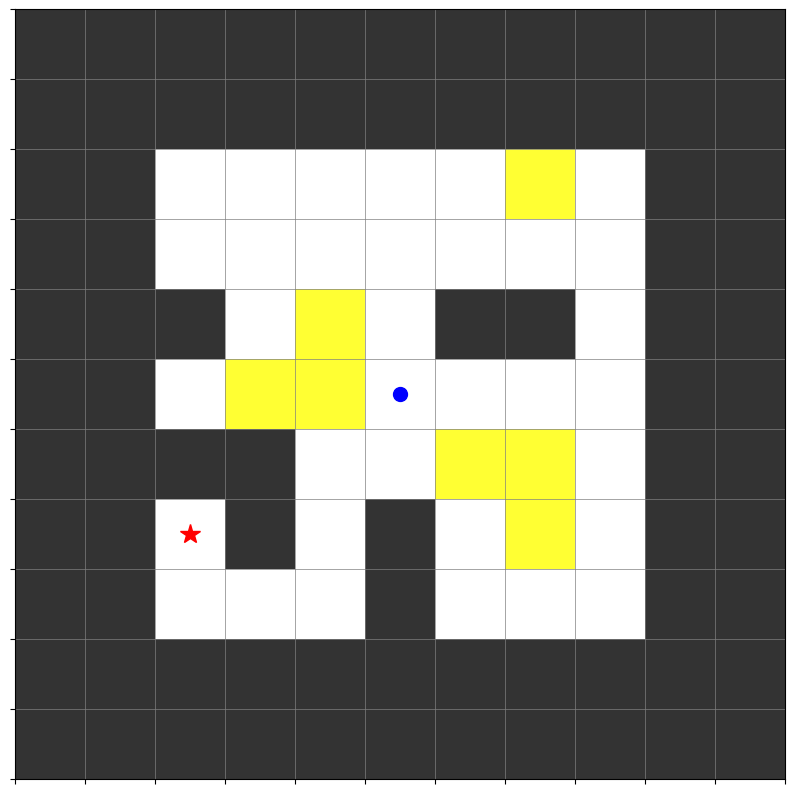


스텝 1:
현재 위치: (5, 5)
선택한 행동: Action.UP
다음 위치: (5, 4)
보상: -0.01


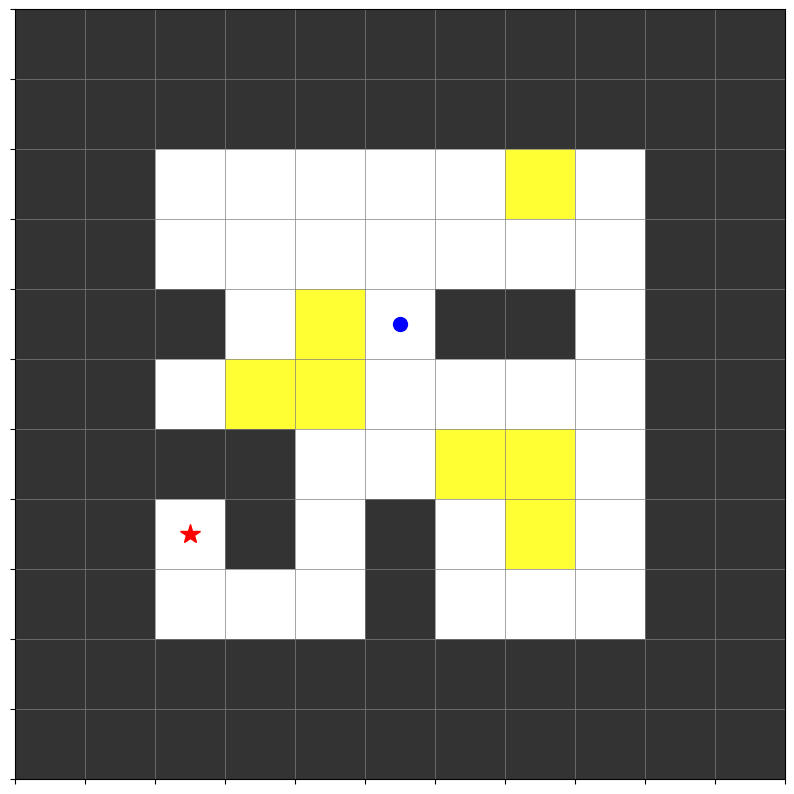


스텝 2:
현재 위치: (5, 4)
선택한 행동: Action.DOWN
다음 위치: (5, 5)
보상: -0.01


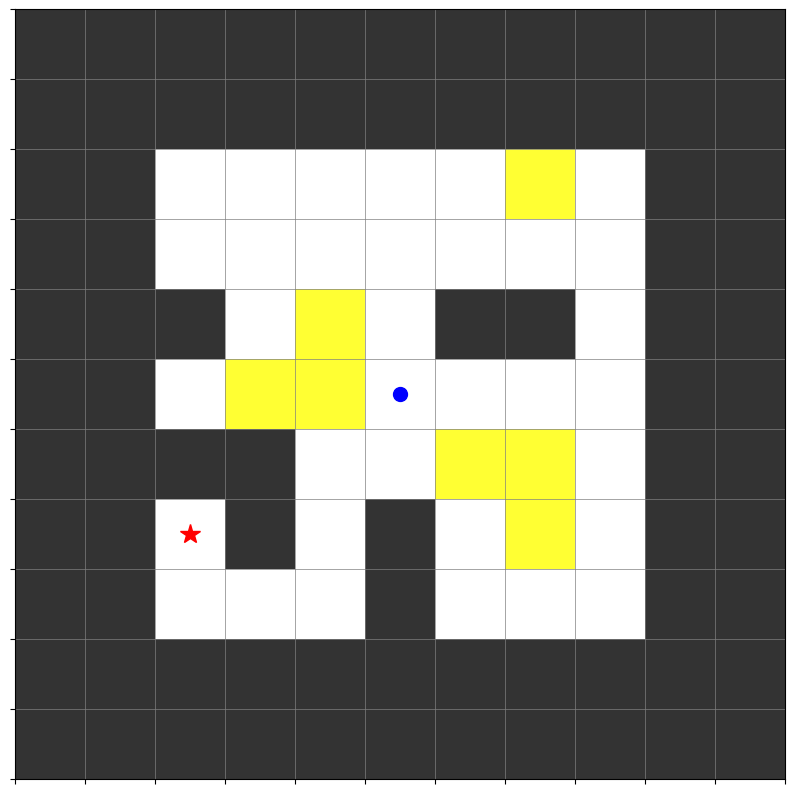


스텝 3:
현재 위치: (5, 5)
선택한 행동: Action.DOWN
다음 위치: (5, 6)
보상: -0.01


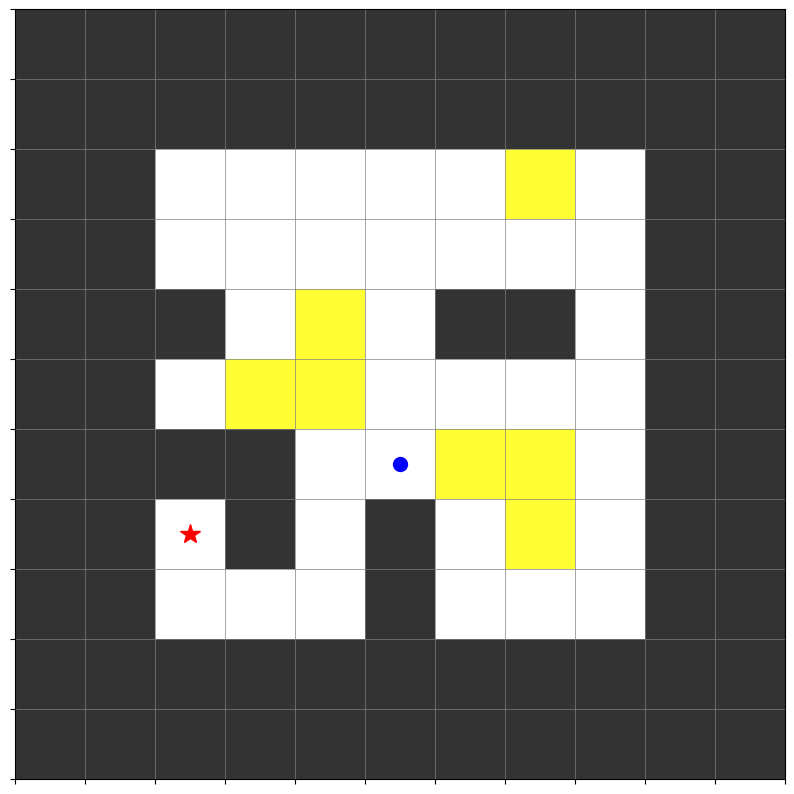


스텝 4:
현재 위치: (5, 6)
선택한 행동: Action.LEFT
다음 위치: (4, 6)
보상: -0.01


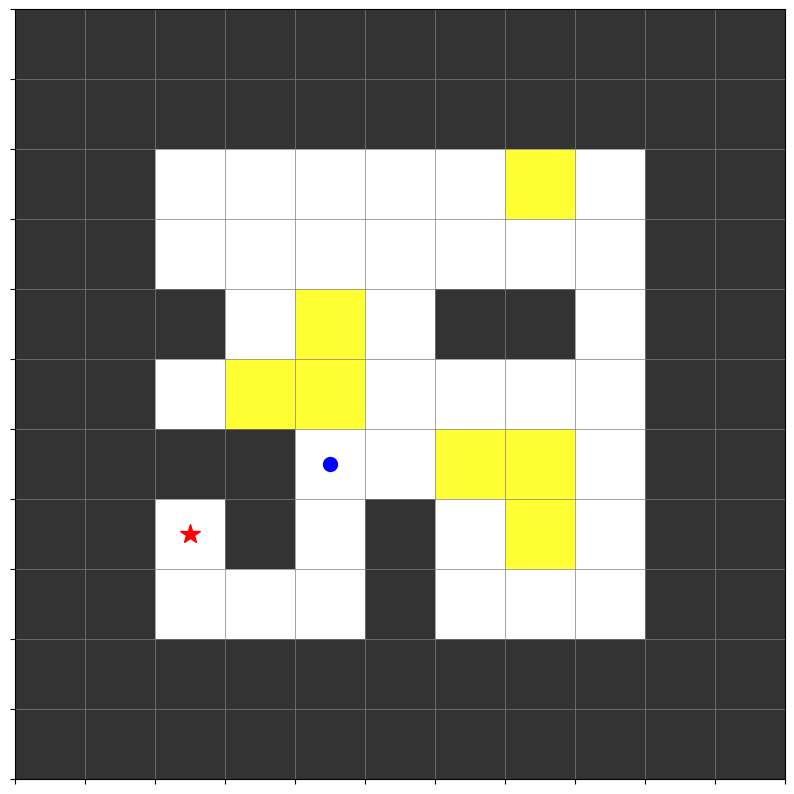


스텝 5:
현재 위치: (4, 6)
선택한 행동: Action.UP
다음 위치: (4, 5)
보상: -0.04


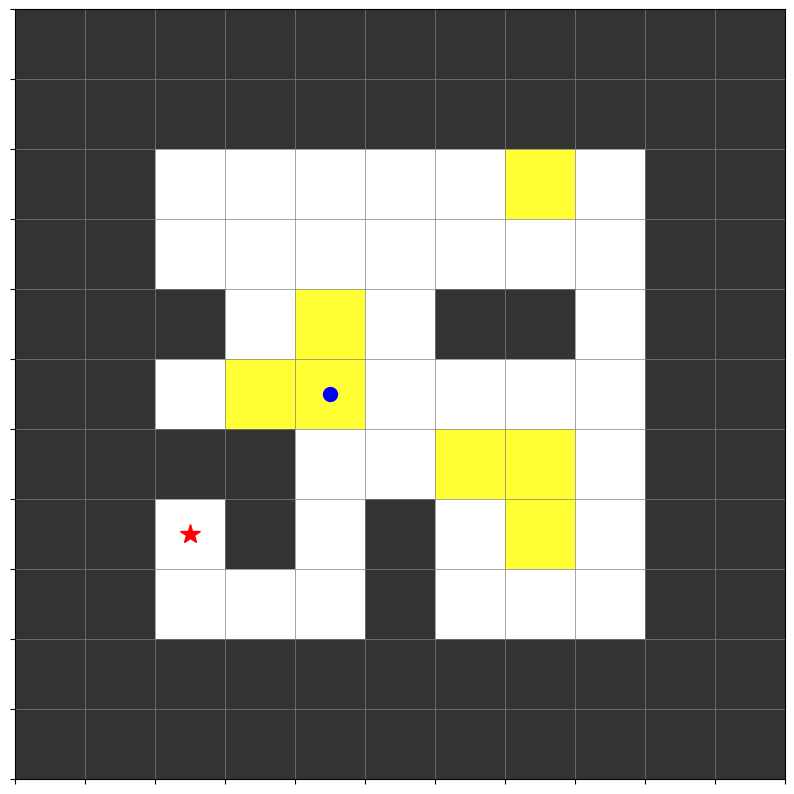


스텝 6:
현재 위치: (4, 5)
선택한 행동: Action.UP
다음 위치: (4, 4)
보상: -0.04


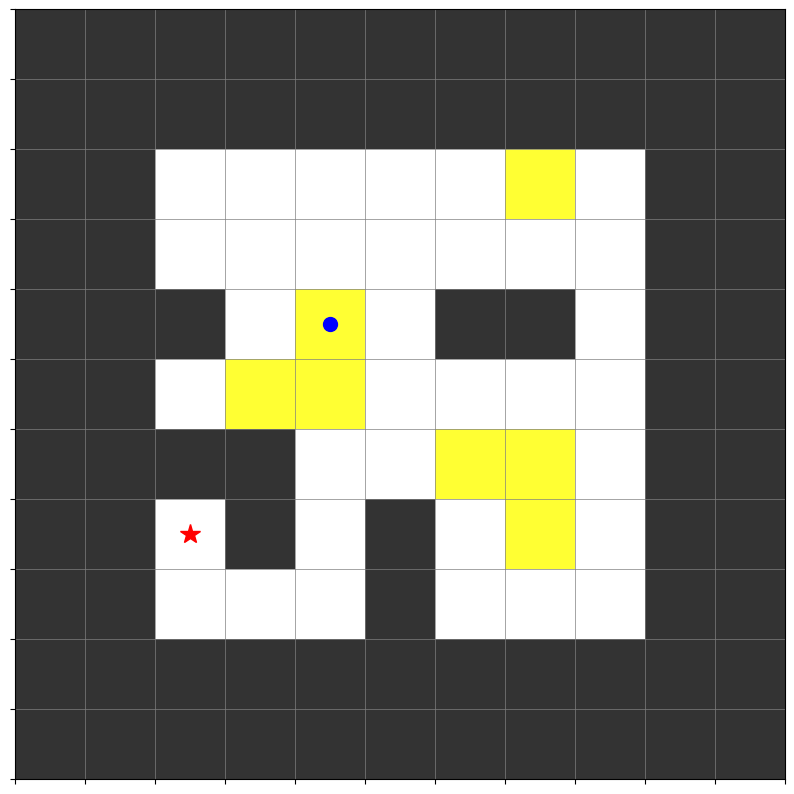


스텝 7:
현재 위치: (4, 4)
선택한 행동: Action.LEFT
다음 위치: (3, 4)
보상: -0.01


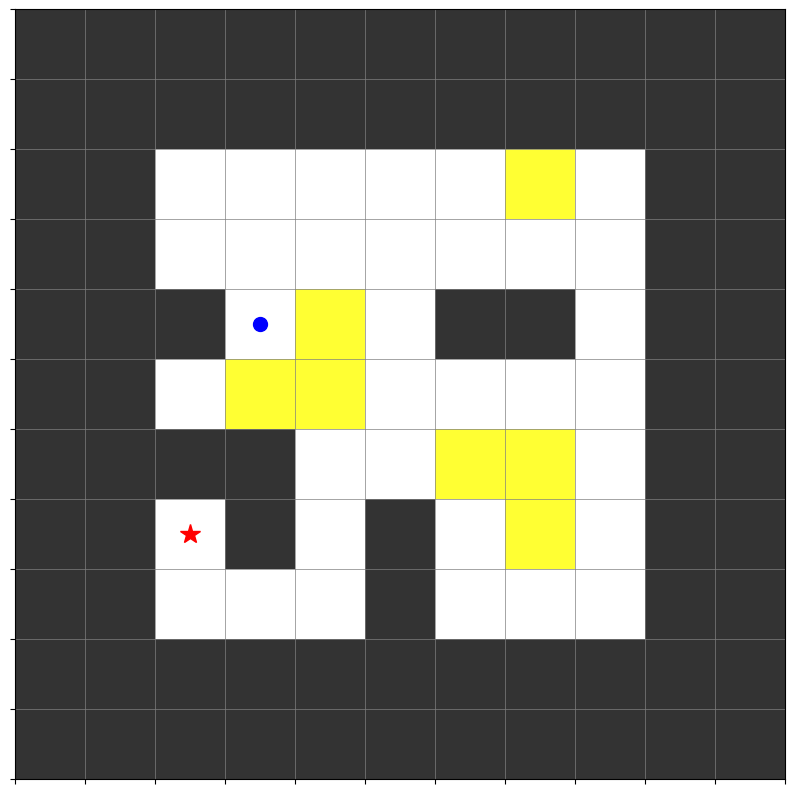


스텝 8:
현재 위치: (3, 4)
선택한 행동: Action.RIGHT
다음 위치: (4, 4)
보상: -0.04


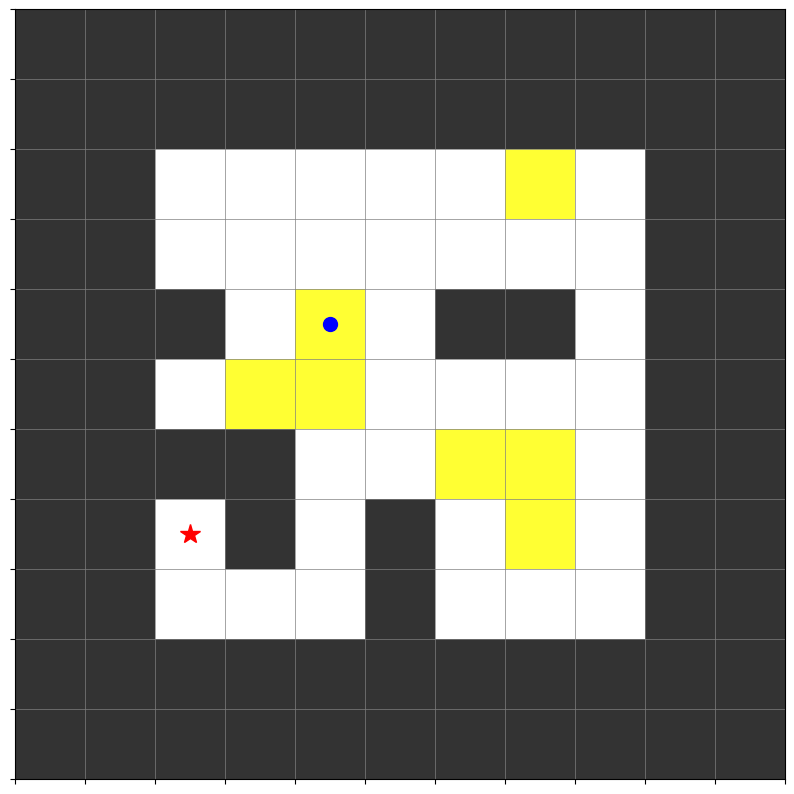


스텝 9:
현재 위치: (4, 4)
선택한 행동: Action.UP
다음 위치: (4, 3)
보상: -0.01


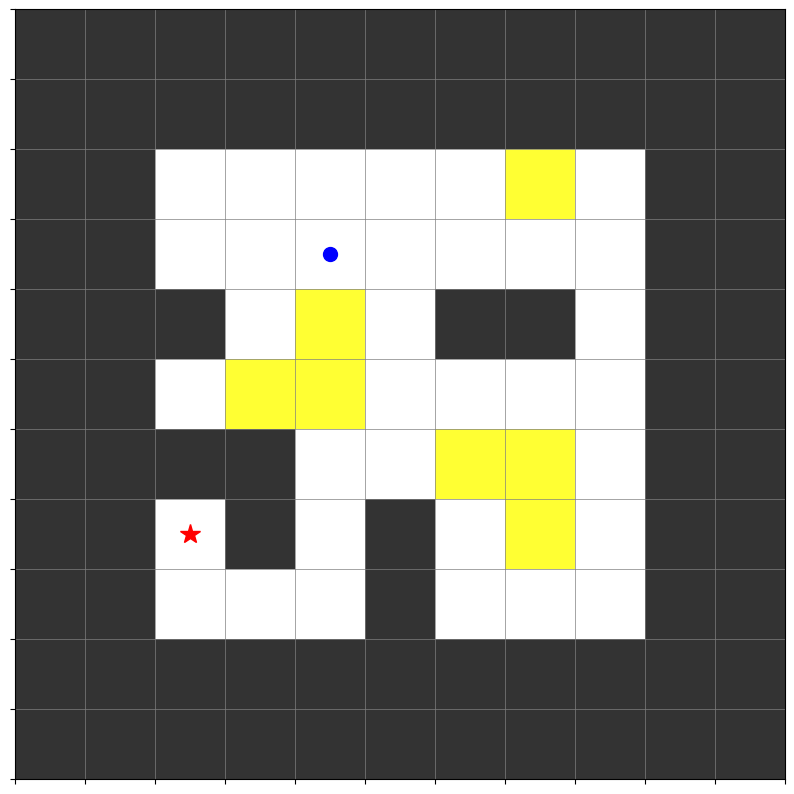


스텝 10:
현재 위치: (4, 3)
선택한 행동: Action.DOWN
다음 위치: (4, 4)
보상: -0.08


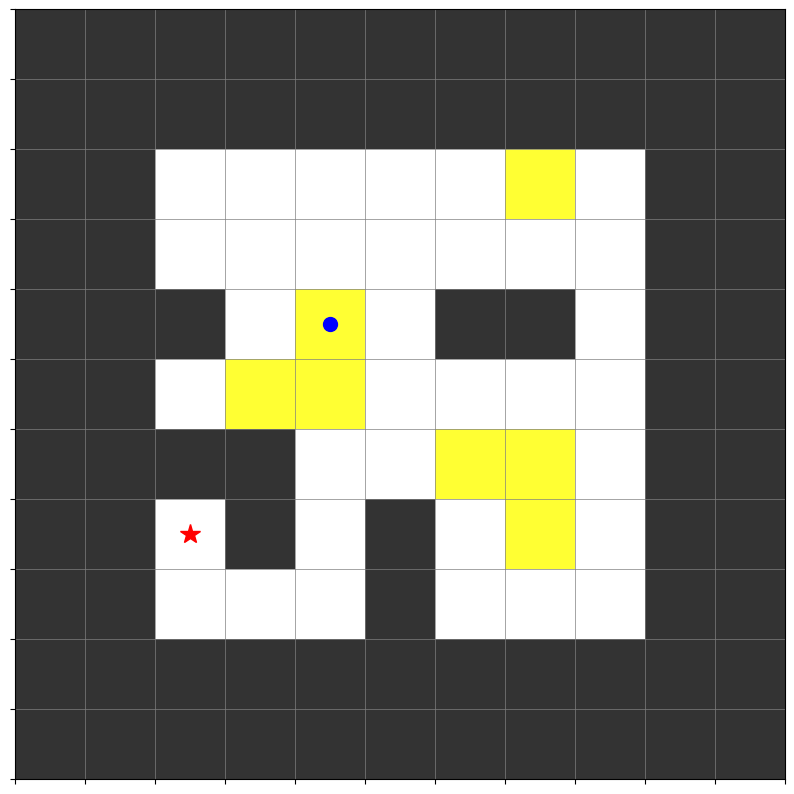


스텝 11:
현재 위치: (4, 4)
선택한 행동: Action.UP
다음 위치: (4, 3)
보상: -0.01


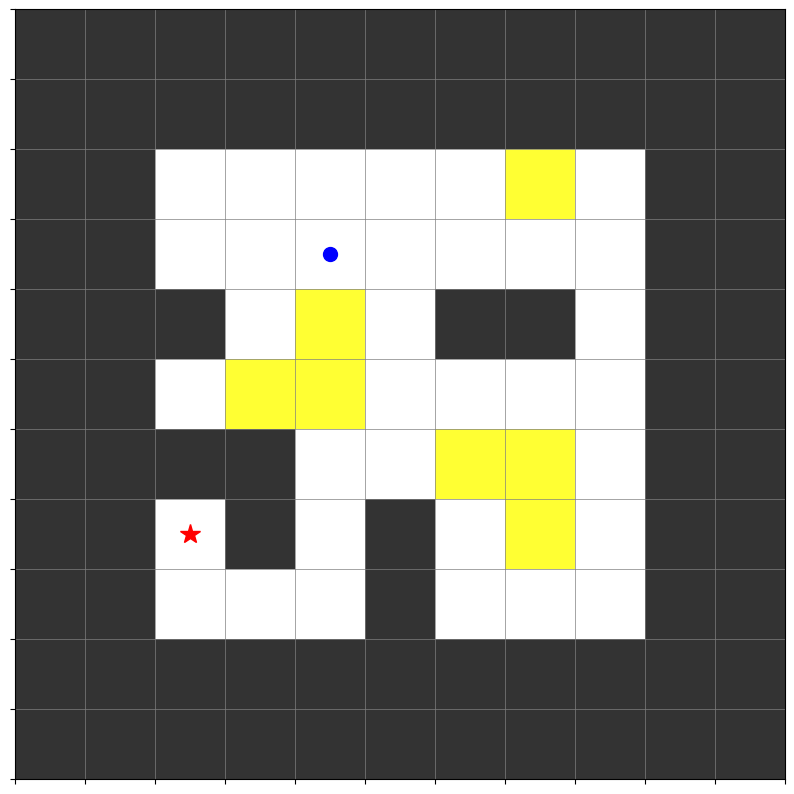


스텝 12:
현재 위치: (4, 3)
선택한 행동: Action.UP
다음 위치: (4, 2)
보상: -0.01


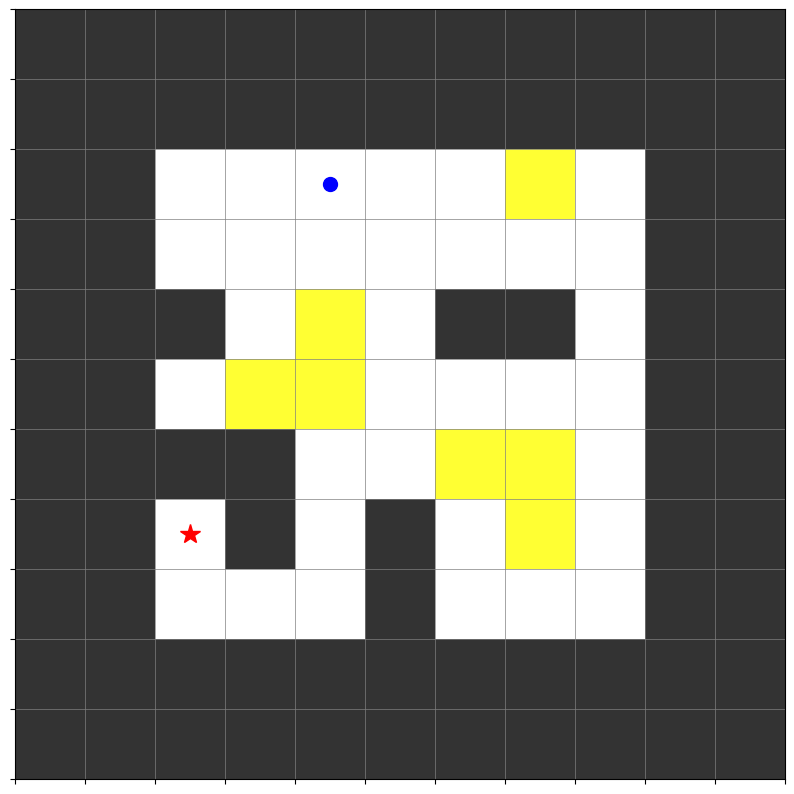


스텝 13:
현재 위치: (4, 2)
선택한 행동: Action.LEFT
다음 위치: (3, 2)
보상: -0.01


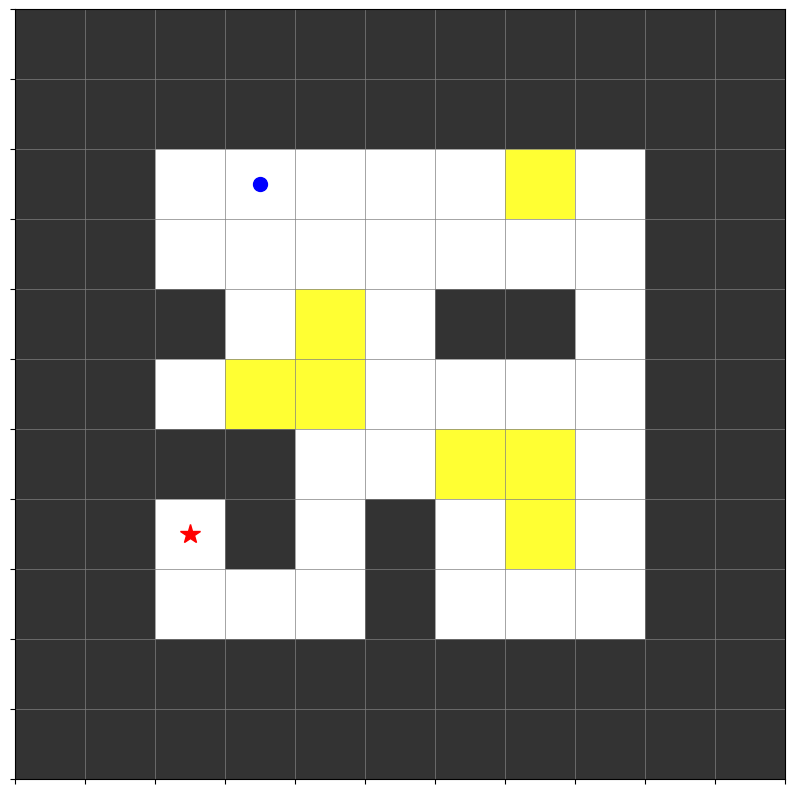


스텝 14:
현재 위치: (3, 2)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.01


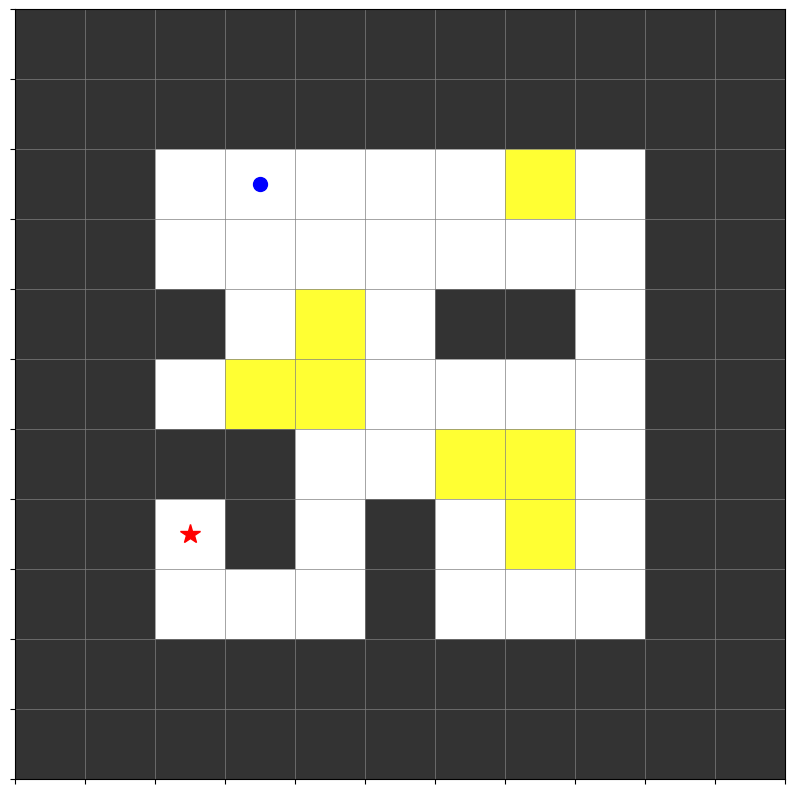


스텝 15:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.01


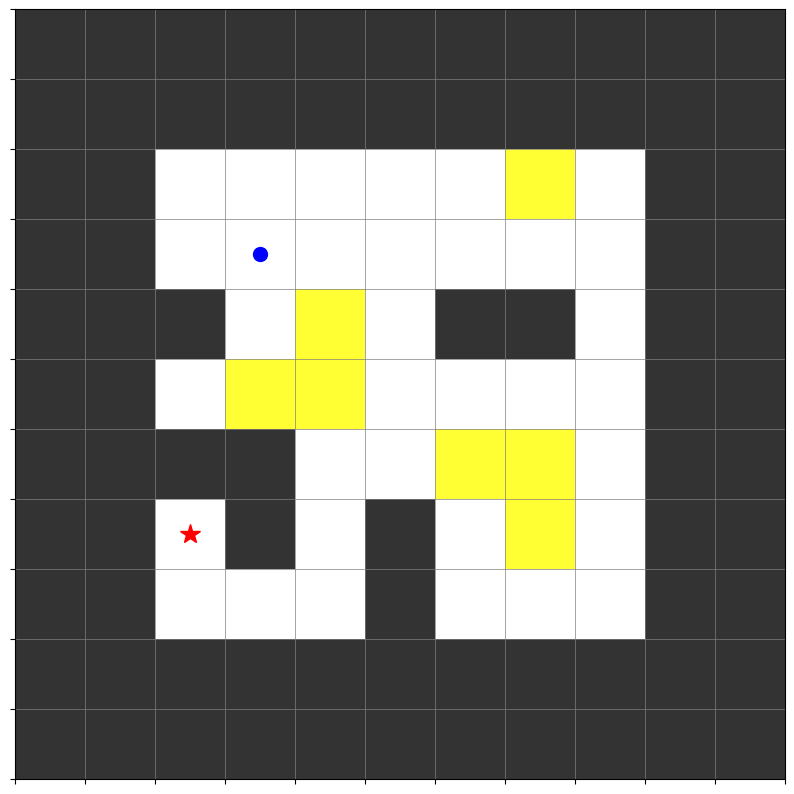


스텝 16:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.05


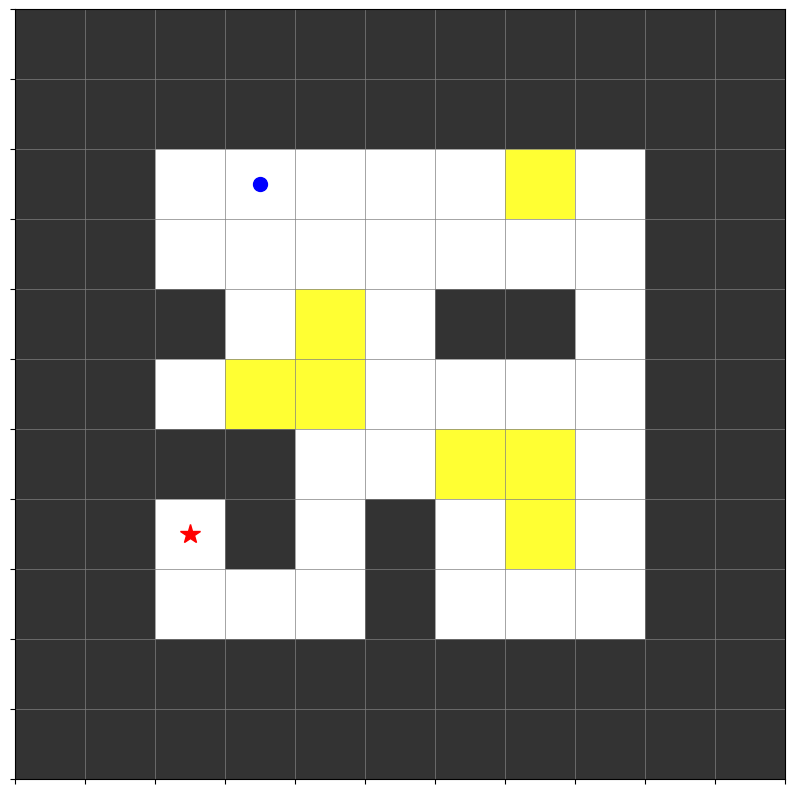


스텝 17:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.01


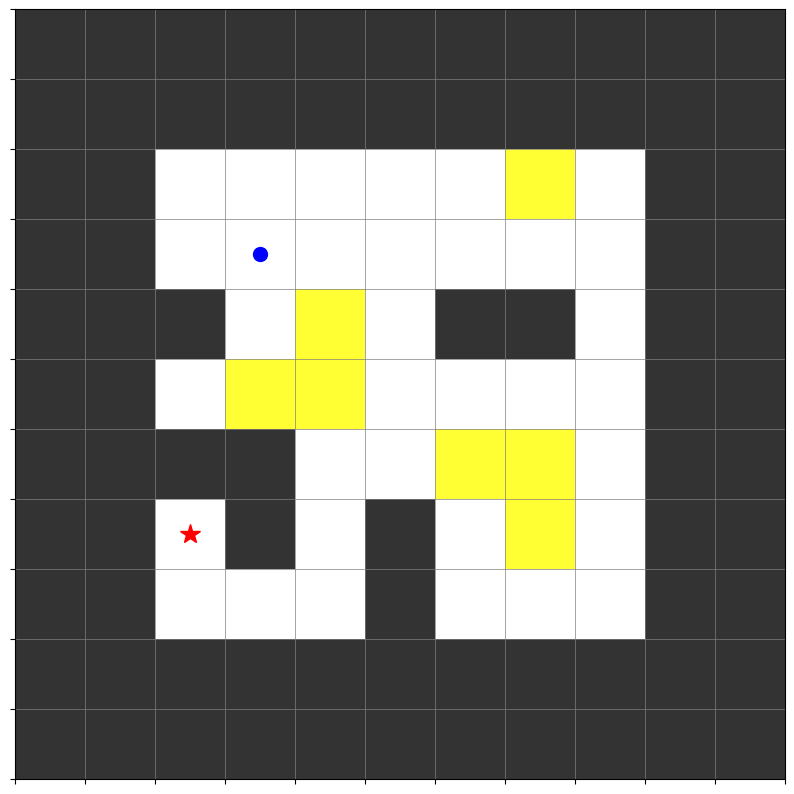


스텝 18:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.07


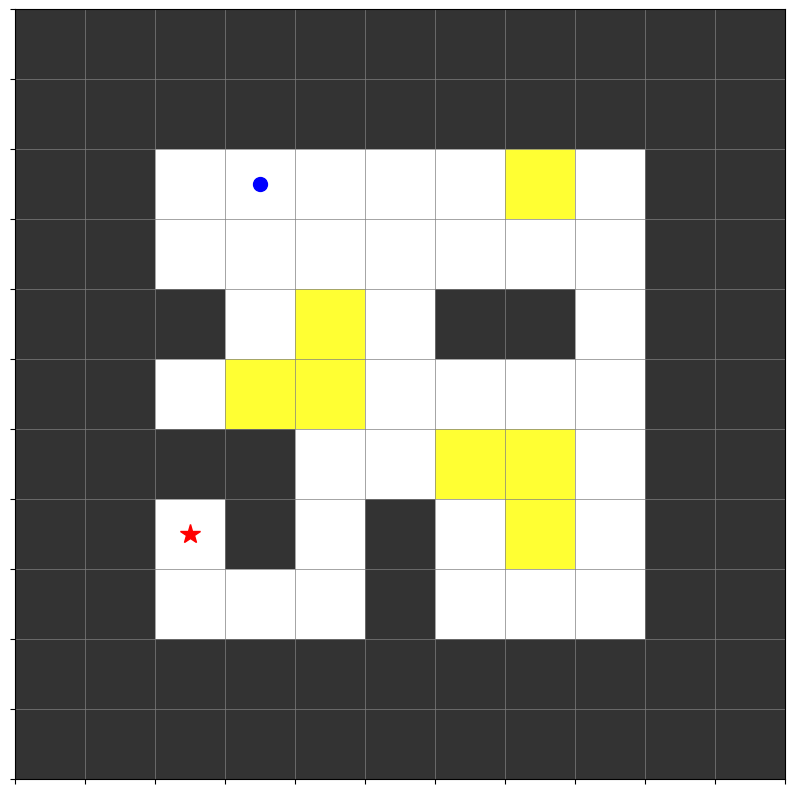


스텝 19:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.05


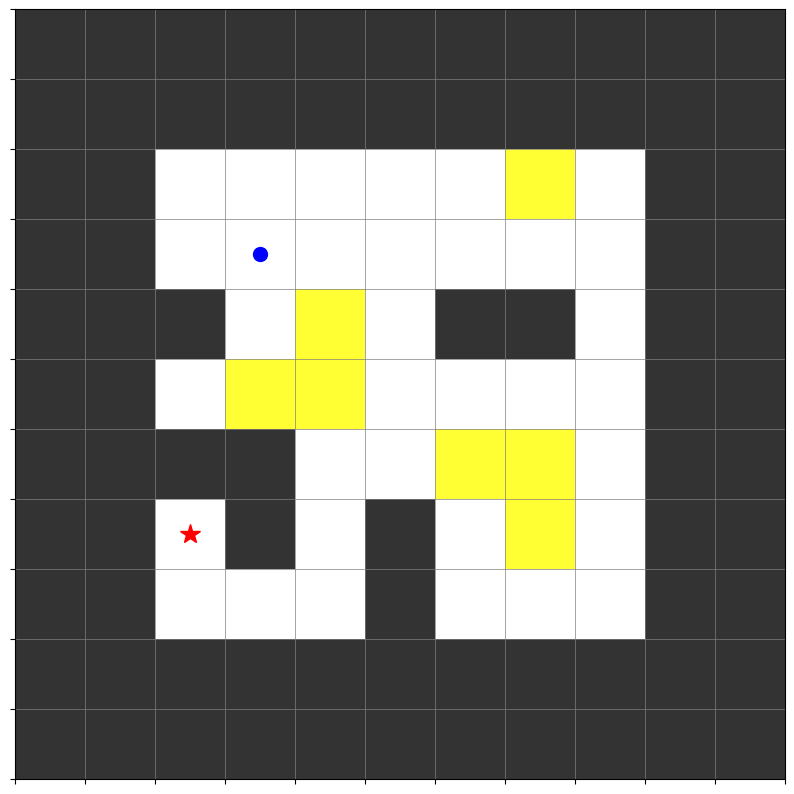


스텝 20:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.09


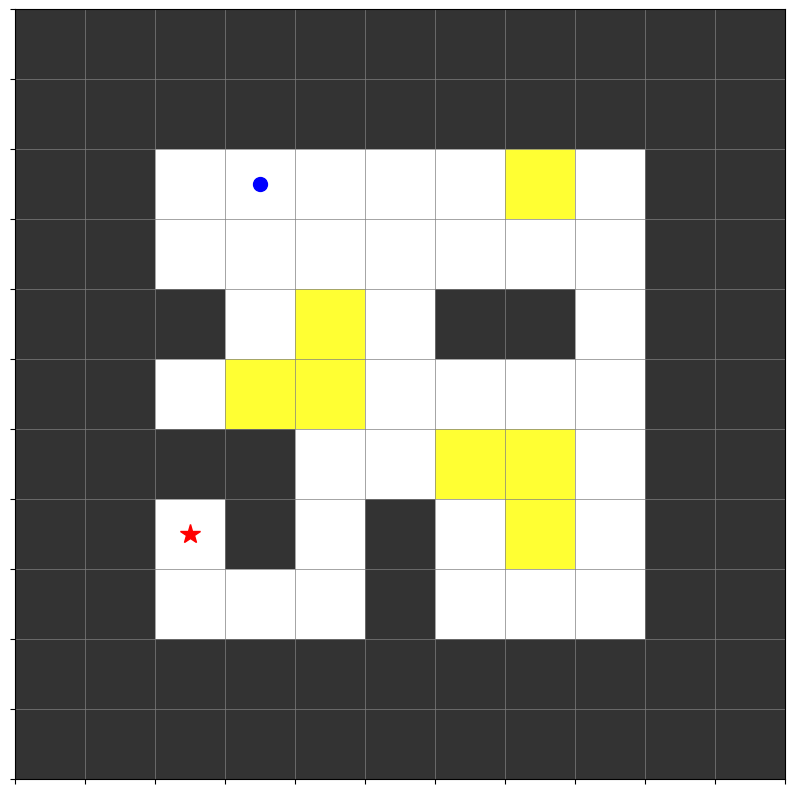


스텝 21:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.07


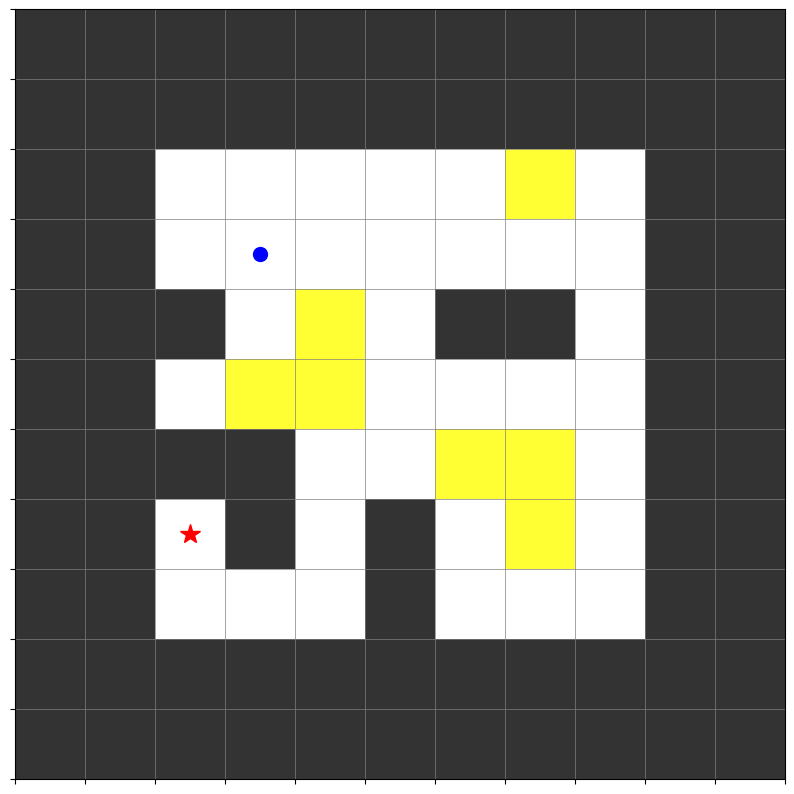


스텝 22:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.11000000000000001


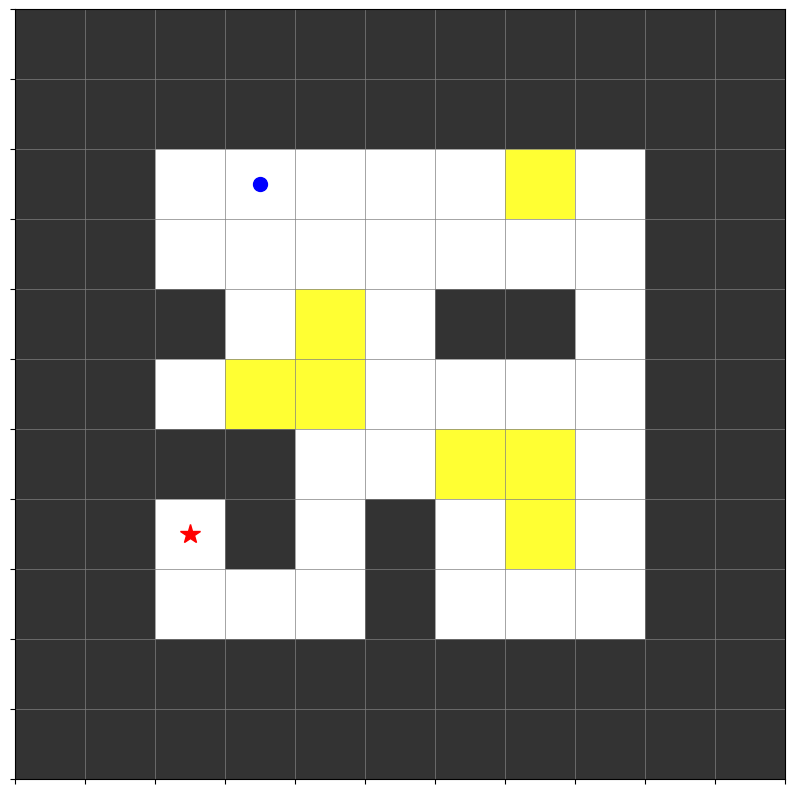


스텝 23:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.09


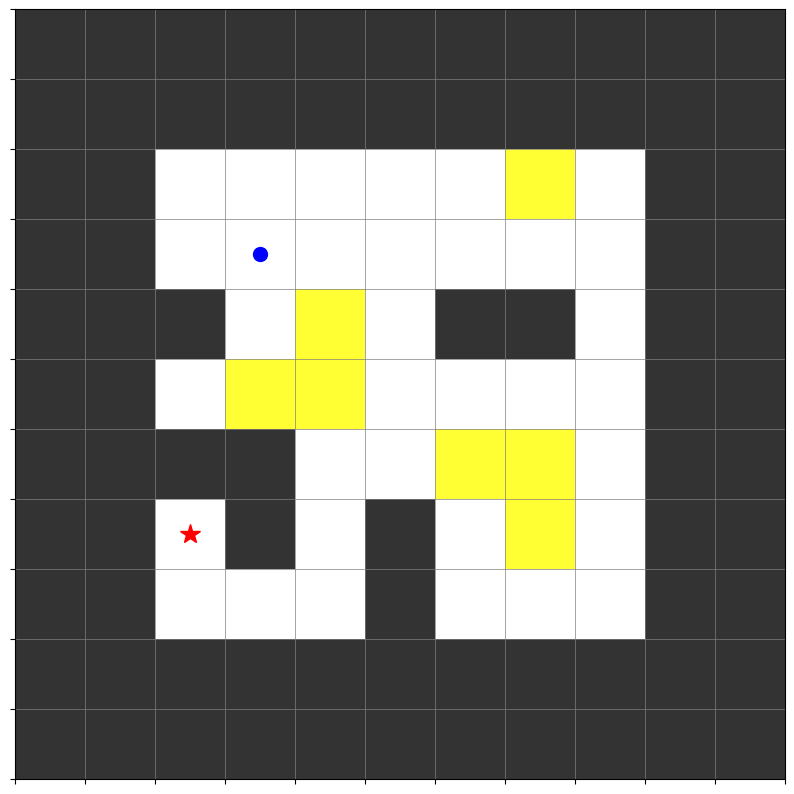


스텝 24:
현재 위치: (3, 3)
선택한 행동: Action.DOWN
다음 위치: (3, 4)
보상: -0.01


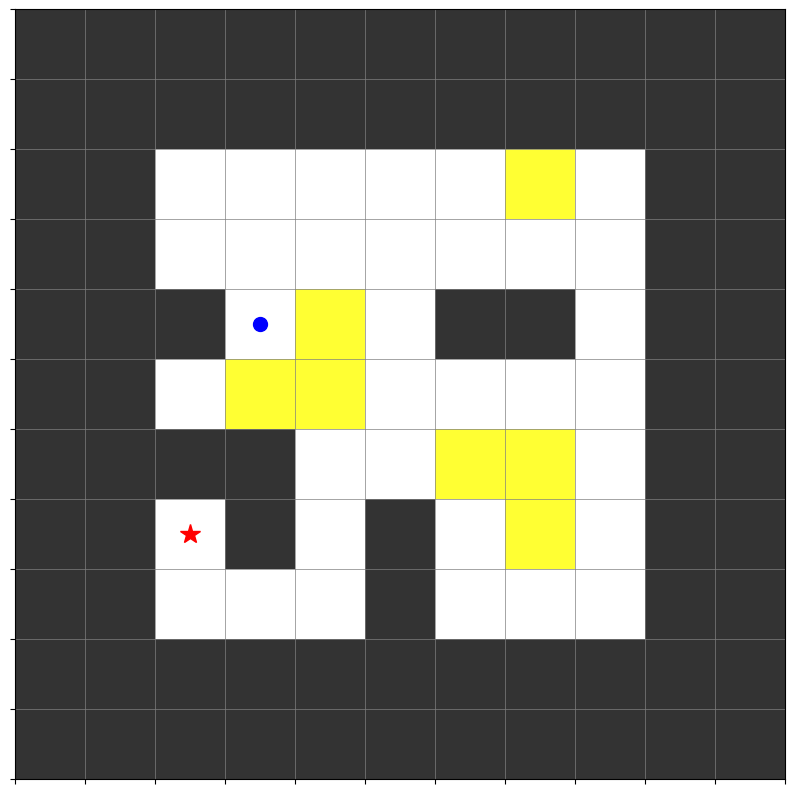


스텝 25:
현재 위치: (3, 4)
선택한 행동: Action.DOWN
다음 위치: (3, 5)
보상: -0.04


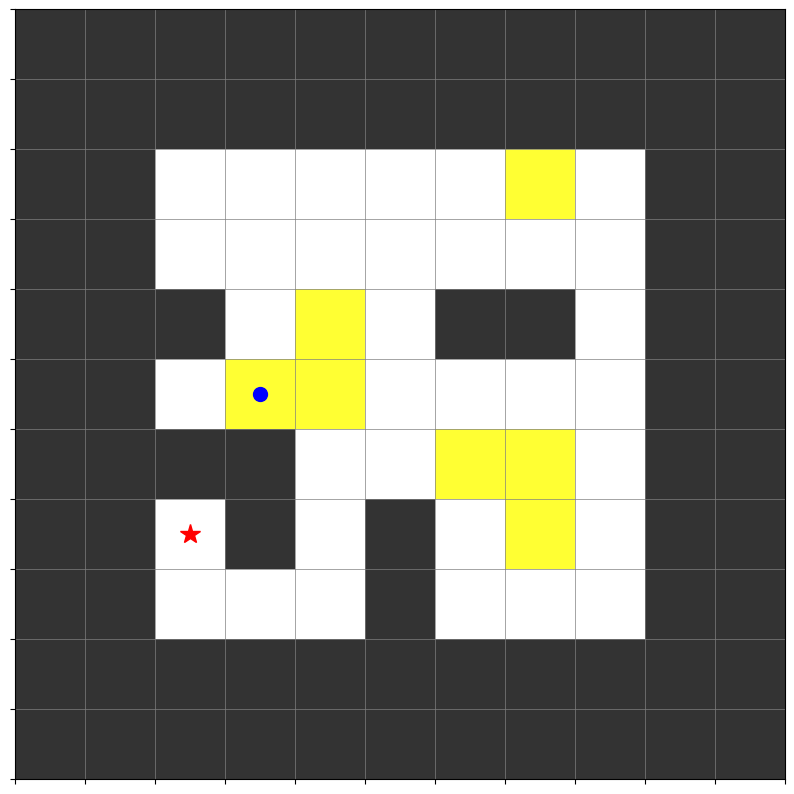


스텝 26:
현재 위치: (3, 5)
선택한 행동: Action.UP
다음 위치: (3, 4)
보상: -0.05


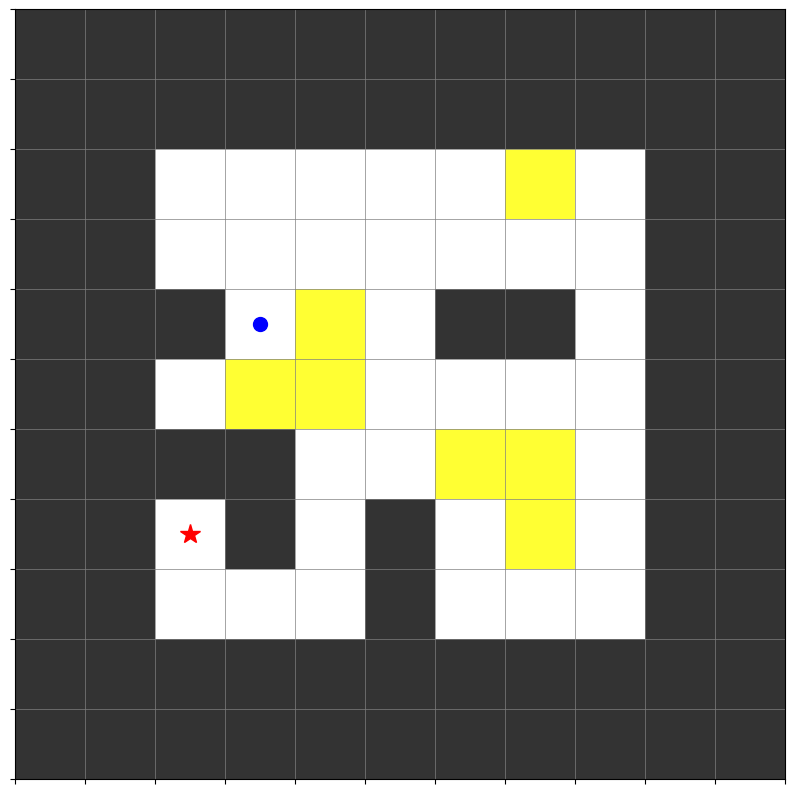


스텝 27:
현재 위치: (3, 4)
선택한 행동: Action.RIGHT
다음 위치: (4, 4)
보상: -0.1


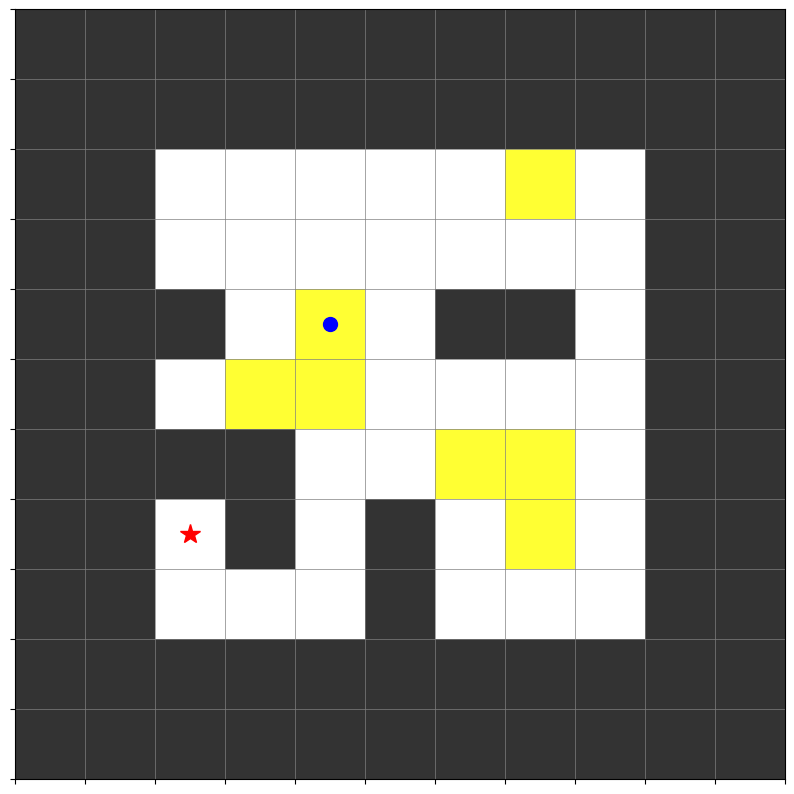


스텝 28:
현재 위치: (4, 4)
선택한 행동: Action.UP
다음 위치: (4, 3)
보상: -0.05


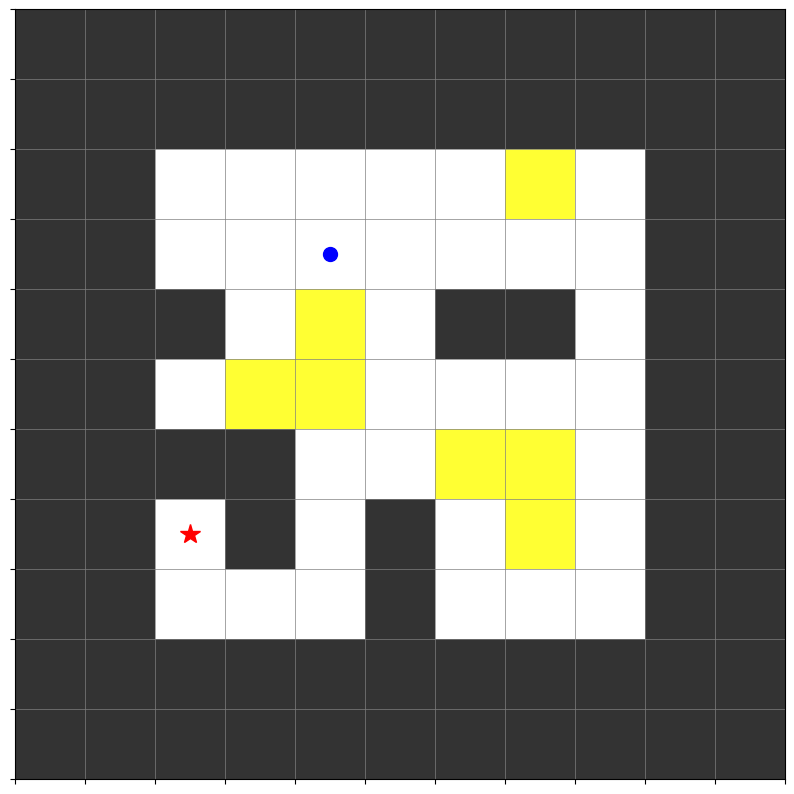


스텝 29:
현재 위치: (4, 3)
선택한 행동: Action.LEFT
다음 위치: (3, 3)
보상: -0.11000000000000001


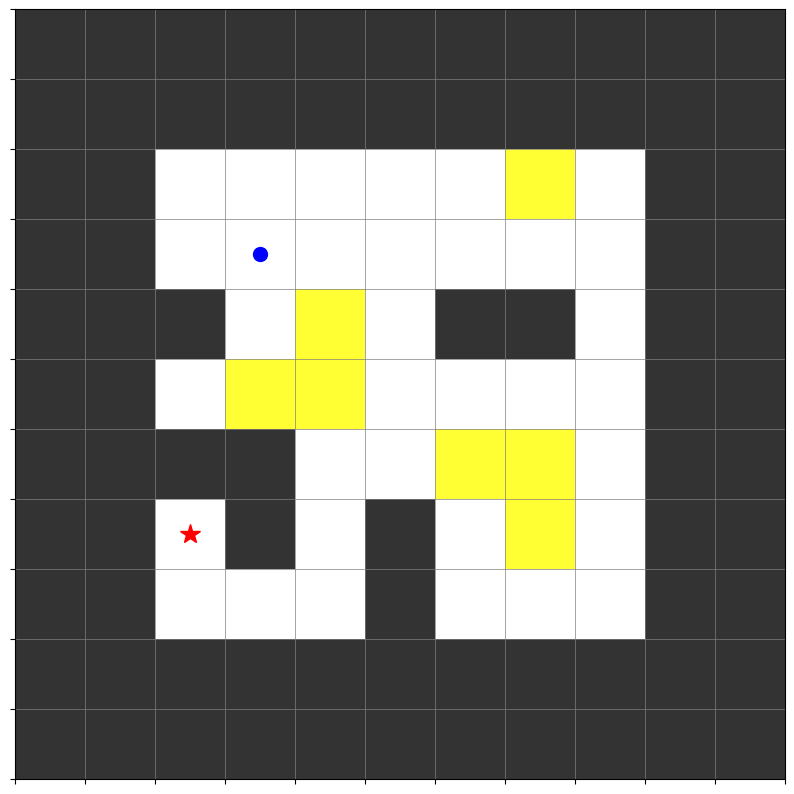


스텝 30:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.13000000000000003


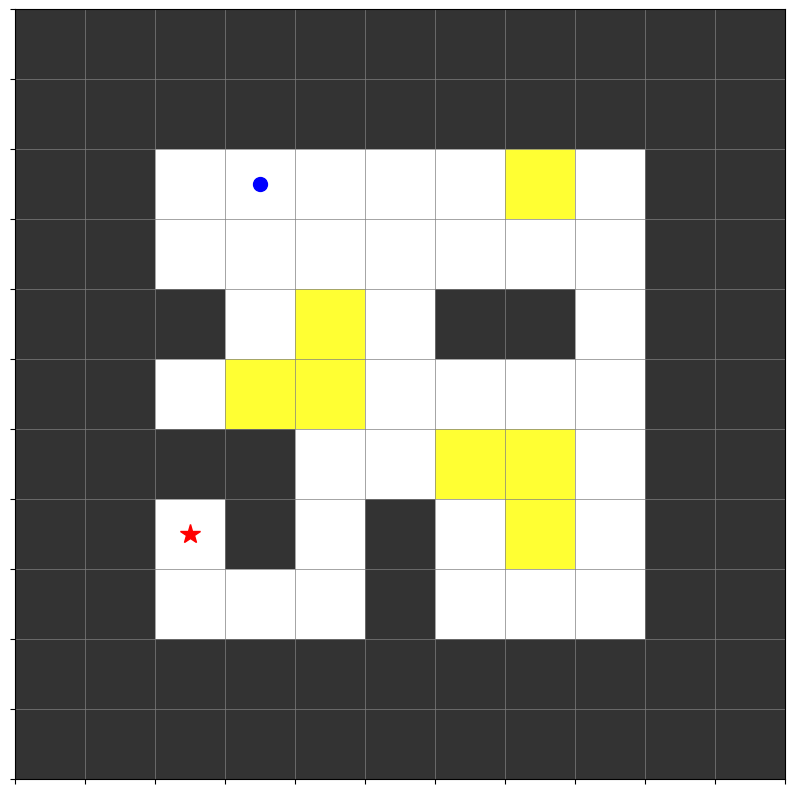


스텝 31:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.13000000000000003


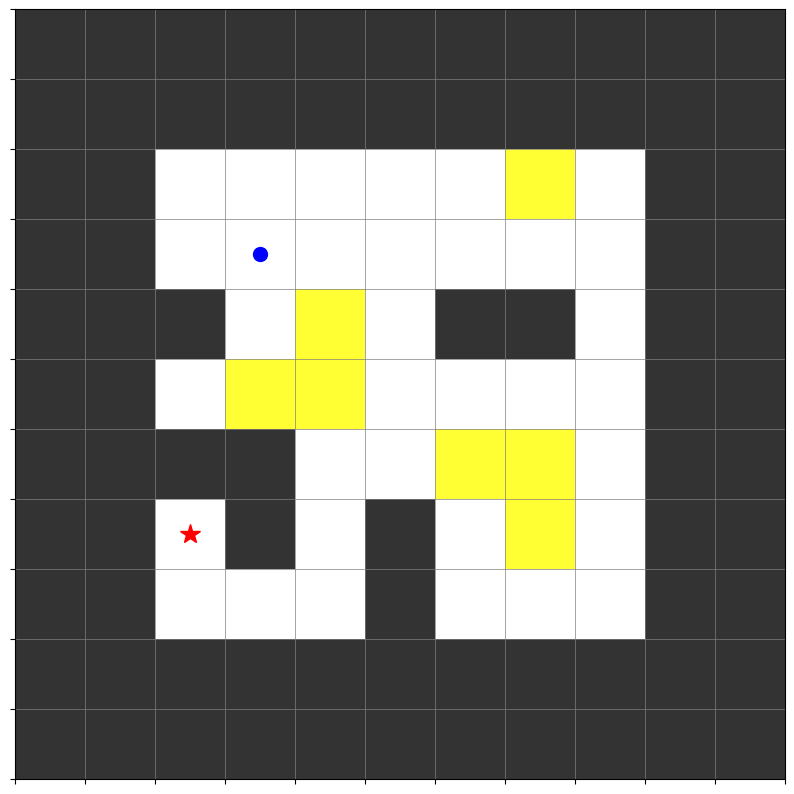


스텝 32:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.15000000000000002


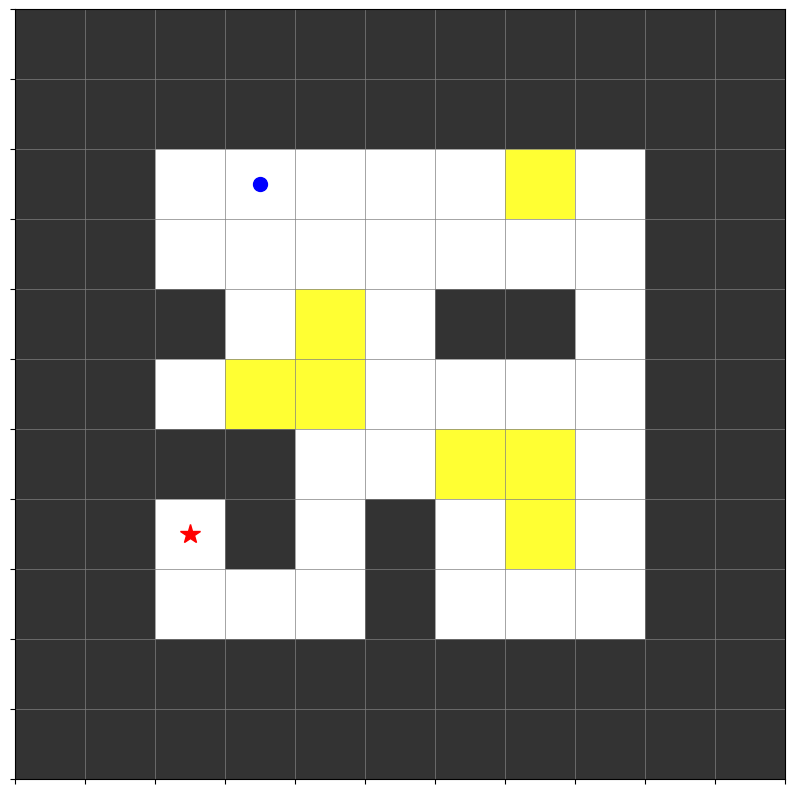


스텝 33:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.15000000000000002


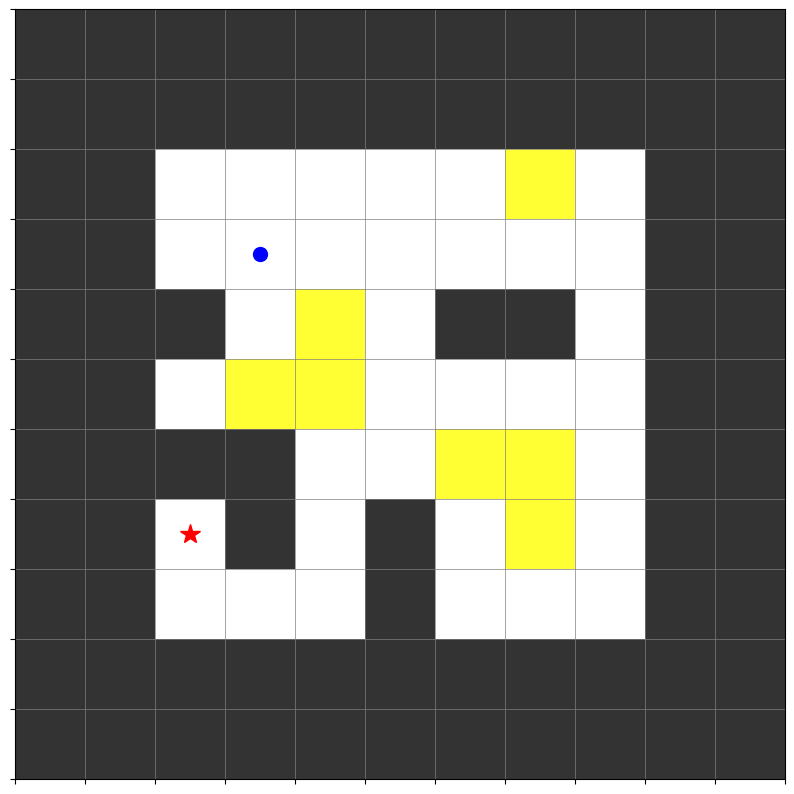


스텝 34:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.17


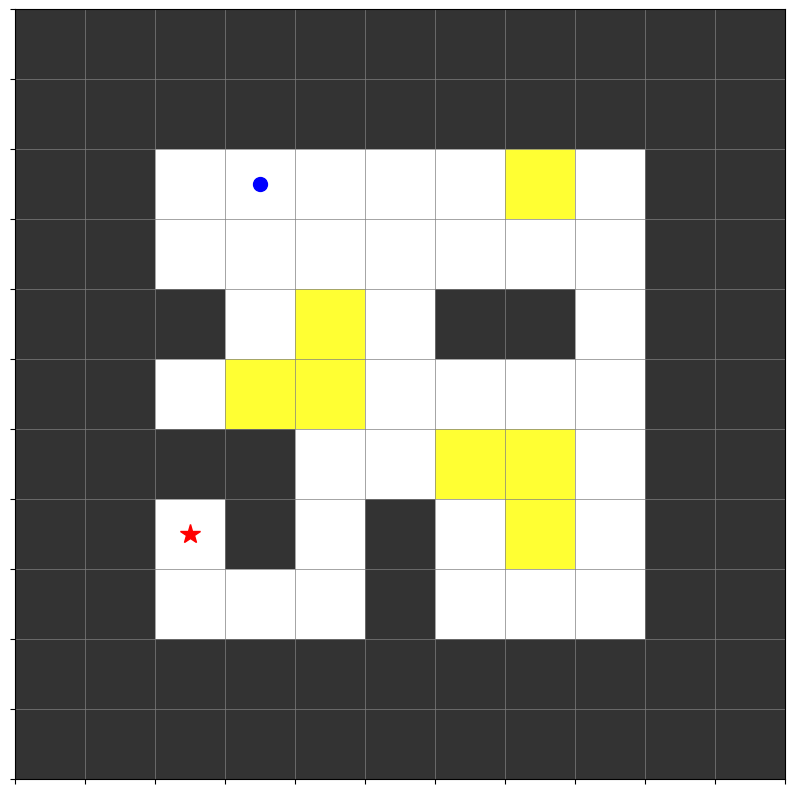


스텝 35:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.17


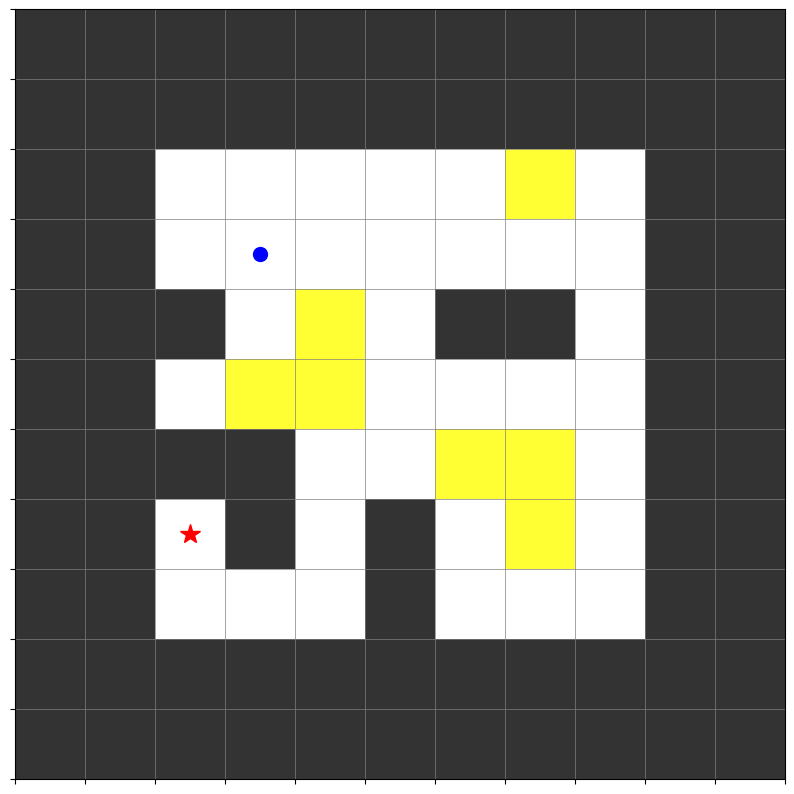


스텝 36:
현재 위치: (3, 3)
선택한 행동: Action.UP
다음 위치: (3, 2)
보상: -0.19


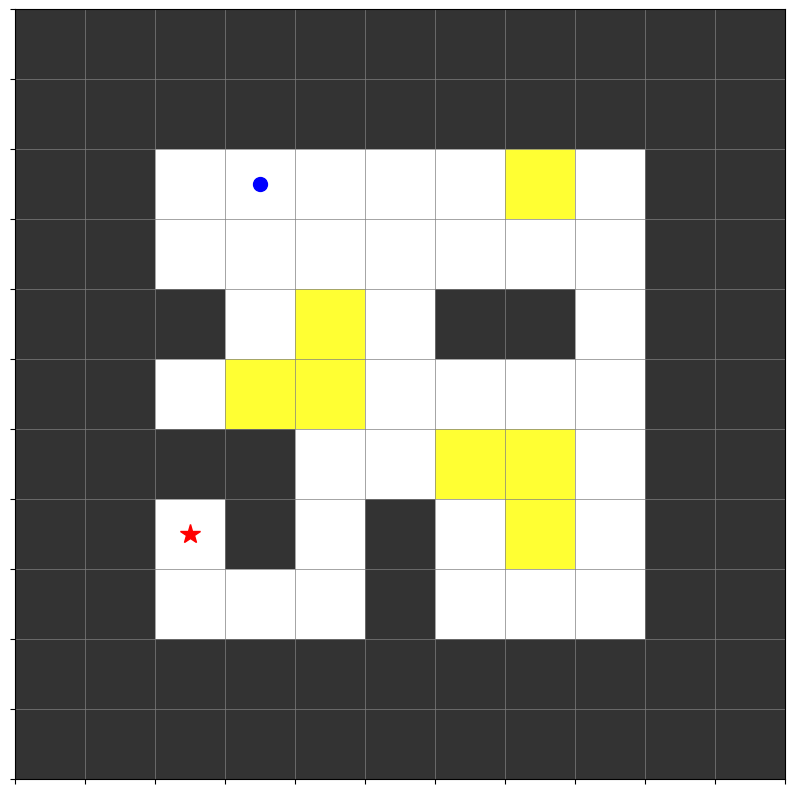


스텝 37:
현재 위치: (3, 2)
선택한 행동: Action.DOWN
다음 위치: (3, 3)
보상: -0.19


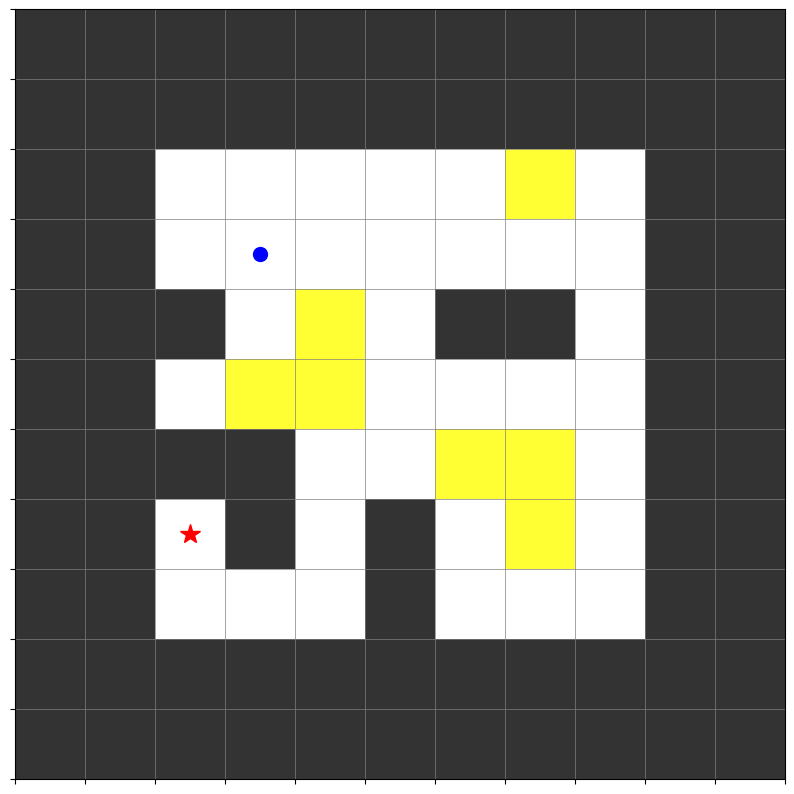


스텝 38:
현재 위치: (3, 3)
선택한 행동: Action.DOWN
다음 위치: (3, 4)
보상: -0.07


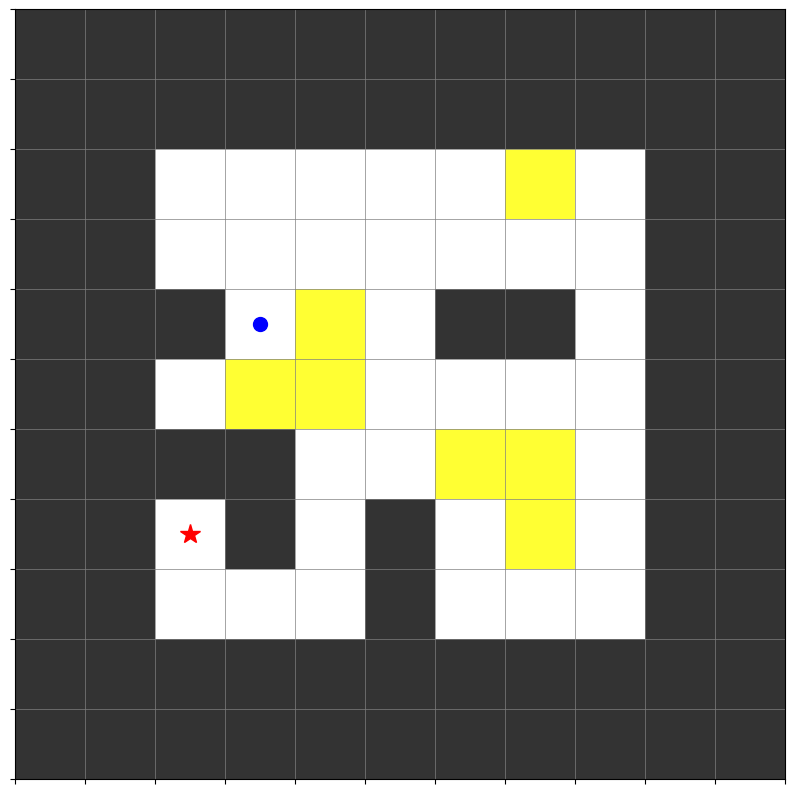


스텝 39:
현재 위치: (3, 4)
선택한 행동: Action.LEFT
다음 위치: (3, 4)
보상: -0.09


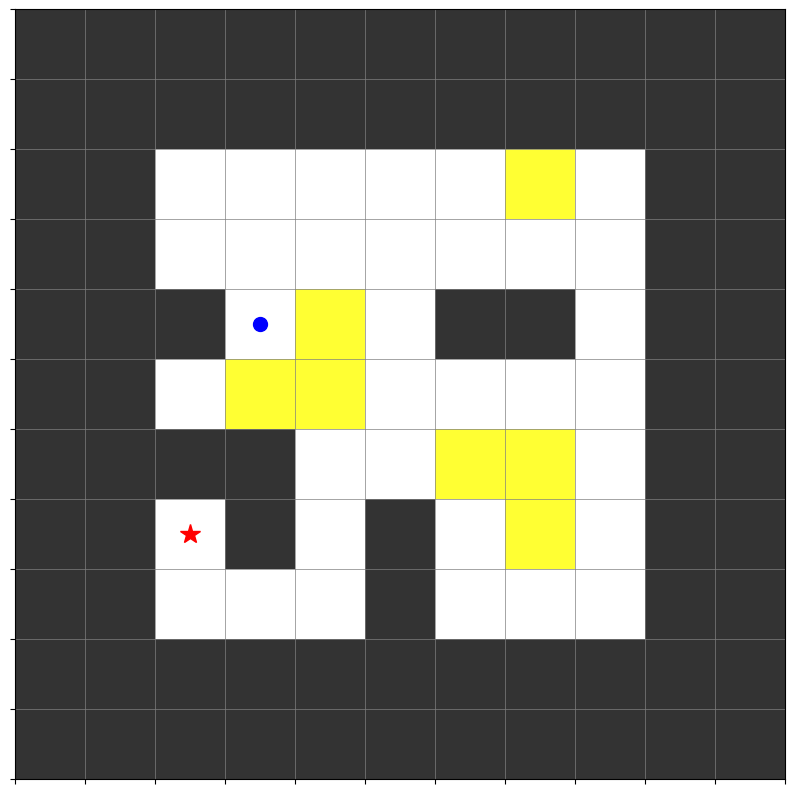


스텝 40:
현재 위치: (3, 4)
선택한 행동: Action.UP
다음 위치: (3, 3)
보상: -0.21000000000000002


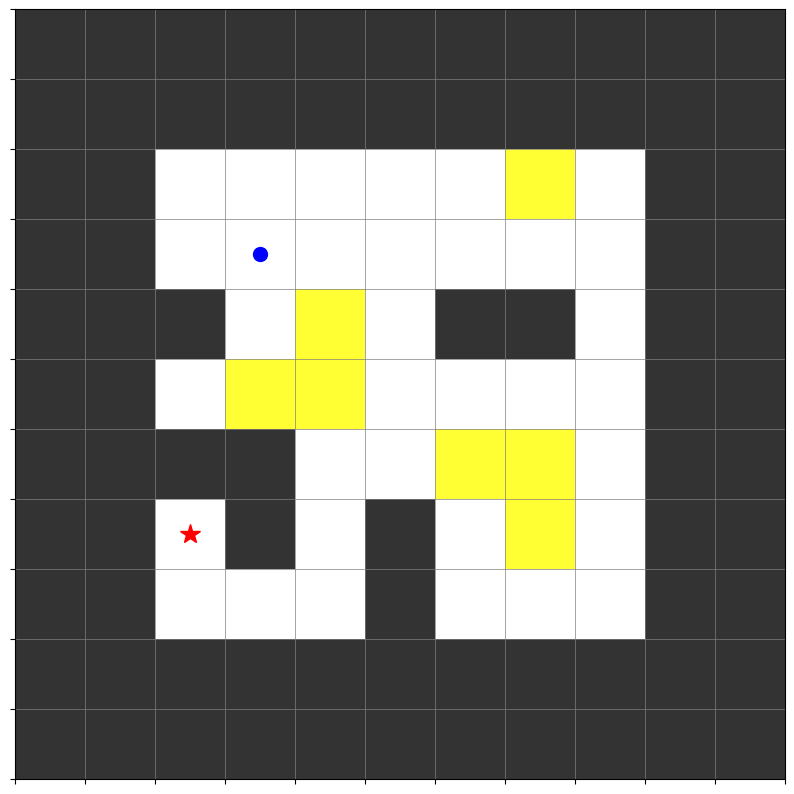


스텝 41:
현재 위치: (3, 3)
선택한 행동: Action.DOWN
다음 위치: (3, 4)
보상: -0.11000000000000001


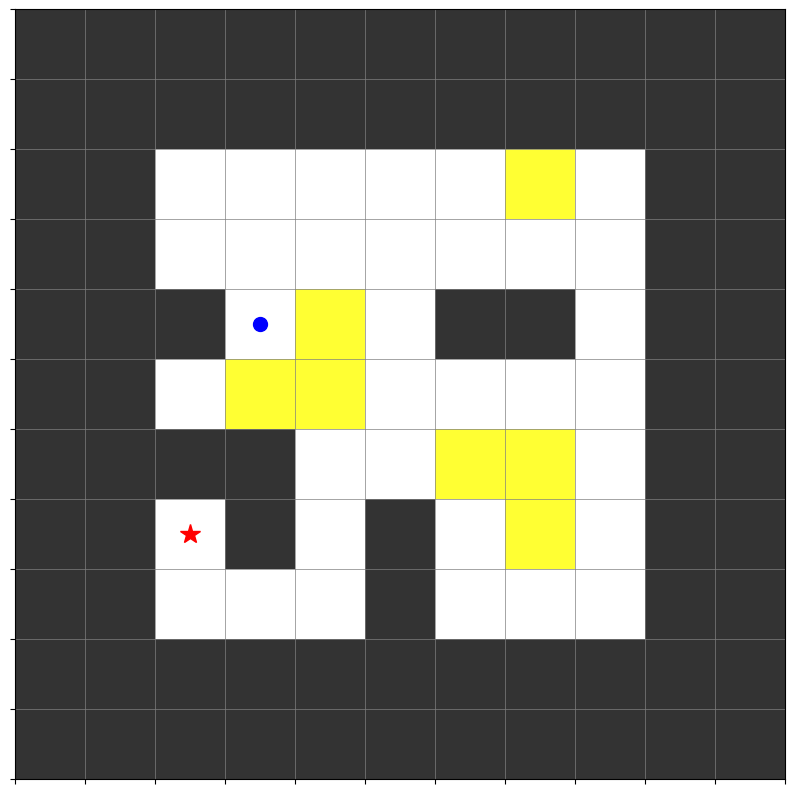


스텝 42:
현재 위치: (3, 4)
선택한 행동: Action.DOWN
다음 위치: (3, 5)
보상: -0.04


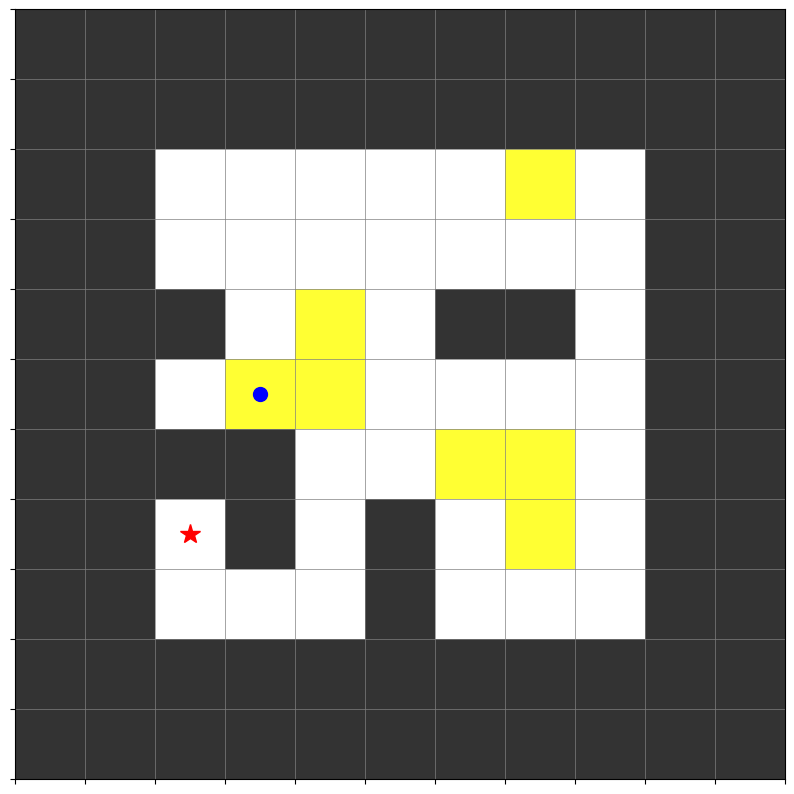


스텝 43:
현재 위치: (3, 5)
선택한 행동: Action.RIGHT
다음 위치: (4, 5)
보상: -0.04


KeyboardInterrupt: 

In [6]:
# 테스트 실행
test_agent(grid_world_1, agent)